In [1]:
import matplotlib.pyplot as plt


from model_ranking.datasets import DummySelfTrainingDataset
from model_ranking.self_training import weak_augmentations

INFO: P [MainThread] 2025-06-17 14:08:45,691 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [2]:
from typing import Dict, Any

data_cfg: Dict[str, Any] = {
    "unsupervised_train_paths": "/scratch/talks/data/EPFL/train.h5",
    "unsupervised_val_paths": "/scratch/talks/data/EPFL/val.h5",
    "patch_shape": [1, 256, 256],
    "supervised_train_paths": None,
    "supervised_val_paths": None,
    "raw_key": "raw",
    "raw_key_supervised": None,
    "label_key": "labels",
    "batch_size": 32,
    "num_workers": 32,
    "n_samples_train": None,
    "n_samples_val": None
}

In [3]:
augmentations = (  # pyright: ignore[reportUnknownVariableType]
        weak_augmentations(),
        weak_augmentations(),
    )

In [4]:
dataset = DummySelfTrainingDataset(
    raw_path = data_cfg["unsupervised_train_paths"],
    raw_key= data_cfg["raw_key"],
    label_path = data_cfg["unsupervised_train_paths"],
    label_key = data_cfg["label_key"],
    patch_shape = data_cfg["patch_shape"],
    n_samples=20,
    augmentations=augmentations,
)

In [5]:
len(dataset)

20

In [6]:
raw1_label, raw2 = dataset[0]
print(raw1_label.shape, raw2.shape)

torch.Size([2, 1, 256, 256]) torch.Size([1, 1, 256, 256])


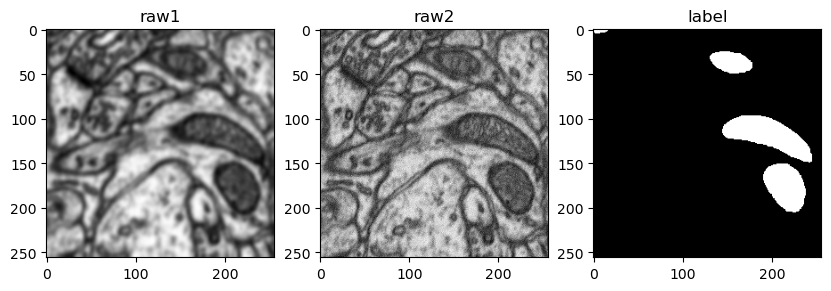

In [7]:
raw1_label, raw2 = dataset[0]
_, axs = plt.subplots(1, 3, figsize=(10, 5))
axs = axs.flatten()
axs[0].imshow(raw1_label[0].numpy().squeeze(), label="raw1", cmap="grey")
axs[1].imshow(raw2.numpy().squeeze(), label="raw2", cmap="grey")
axs[2].imshow(raw1_label[1].numpy().squeeze(), label="label", cmap="grey")
axs[0].set_title("raw1")
axs[1].set_title("raw2")
axs[2].set_title("label")
plt.show()